# Pose Estimation Algorithm
### Imports

In [15]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math
from mclasses.Pose import Pose
from mclasses.PoseObject import PoseObject
from mclasses.FilenamesHelper import FilenamesHelper

# Set up matplotlib for inline viewing
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load Camera Calibrations

In [16]:
def load_camera_intrinsics():
    """Loads the RGB camera matrix from the calibrations file."""
    # Use your new helper to get the path
    calib_path = FilenamesHelper.get_camera_calibrations_file_path()

    fs = cv2.FileStorage(calib_path, cv2.FILE_STORAGE_READ)

    # Read the correct node
    camera_matrix = fs.getNode("rgb_calibration").mat()
    fs.release()

    # Assume zero distortion if not provided in the calibration file
    dist_coeffs = np.zeros((4, 1), dtype=np.float32)

    return camera_matrix, dist_coeffs

In [17]:
# Load intrinsics
K, dist_coeffs = load_camera_intrinsics()
print("Camera Matrix:\n", K)
print("Distortion Coefficients:\n", dist_coeffs)

Camera Matrix:
 [[575.81573   0.      319.5    ]
 [  0.      575.81573 239.5    ]
 [  0.        0.        1.     ]]
Distortion Coefficients:
 [[0.]
 [0.]
 [0.]
 [0.]]


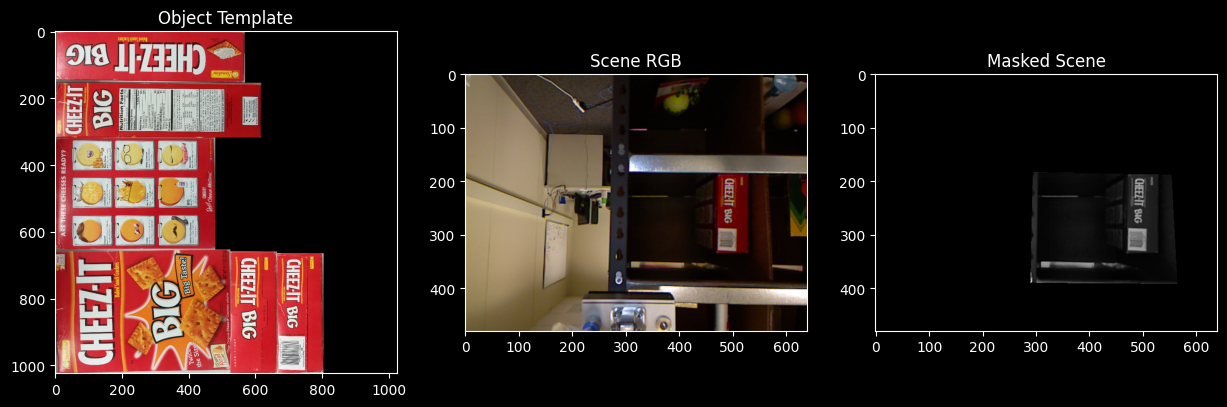

In [20]:
# The base filename (without path)
target_filename = "cheezit_big_original-image-F-1-1-0.png"

# Initialize our object. Note: PoseObject's __init__ will automatically use
# FilenamesHelper to find and load the ground truth pose!
obj_data = PoseObject(target_filename)

# Load the images using the new FilenamesHelper paths
rgb_img = cv2.imread(FilenamesHelper.get_image_file_path(obj_data, run_number=1))
depth_img = cv2.imread(FilenamesHelper.get_depth_file_path(obj_data, run_number=1), cv2.IMREAD_UNCHANGED)
mask_img = cv2.imread(FilenamesHelper.get_mask_file_path(obj_data, run_number=1), cv2.IMREAD_GRAYSCALE)

# Load the texture using the new FilenamesHelper
template_img = cv2.imread(FilenamesHelper.get_texture_file_path(obj_data))

# Convert RGB to Grayscale for feature matching
scene_gray = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)

# Apply the bin mask to the scene to ignore background clutter outside the bin
masked_scene = cv2.bitwise_and(scene_gray, scene_gray, mask=mask_img)

# Quick visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv2.cvtColor(template_img, cv2.COLOR_BGR2RGB)); ax[0].set_title("Object Template")
ax[1].imshow(cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)); ax[1].set_title("Scene RGB")
ax[2].imshow(masked_scene, cmap='gray'); ax[2].set_title("Masked Scene")
plt.show()

In [22]:
def find_feature_matches(templ_gray, scn_gray, num_matches=50):
    """Detects ORB features and finds the best matches between template and scene."""
    # 1. Initialize ORB detector
    orb = cv2.ORB_create(nfeatures=1000)

    # 2. Find keypoints and descriptors
    kp_temp, des_temp = orb.detectAndCompute(templ_gray, None)
    kp_scene, des_scene = orb.detectAndCompute(scn_gray, None)

    # 3. Match features using Brute Force Matcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des_temp, des_scene)

    # Sort matches by distance (lower distance = better match)
    matches = sorted(matches, key=lambda x: x.distance)

    # Keep only the top 'num_matches'
    good_matches = matches[:num_matches]

    return kp_temp, kp_scene, good_matches

In [23]:
def draw_feature_matches(template_img, kp_temp, scene_img, kp_scene, matches):
    """Draws lines connecting the matched keypoints between the two images."""
    # OpenCV has a built-in function specifically for visualizing this!
    matched_vis = cv2.drawMatches(
        template_img, kp_temp,
        scene_img, kp_scene,
        matches, None,
        matchColor=(0, 255, 0), # Green lines for matches
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # Display using matplotlib
    plt.figure(figsize=(15, 8))
    plt.imshow(cv2.cvtColor(matched_vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Top {len(matches)} ORB Feature Matches")
    plt.axis('off')
    plt.show()

In [40]:
# Find the matches between the template and the masked scene
kp_temp, kp_scene, good_matches = find_feature_matches(template_gray, masked_scene, num_matches=100)

print(f"Found {len(good_matches)} high-quality matches!")

Found 100 high-quality matches!


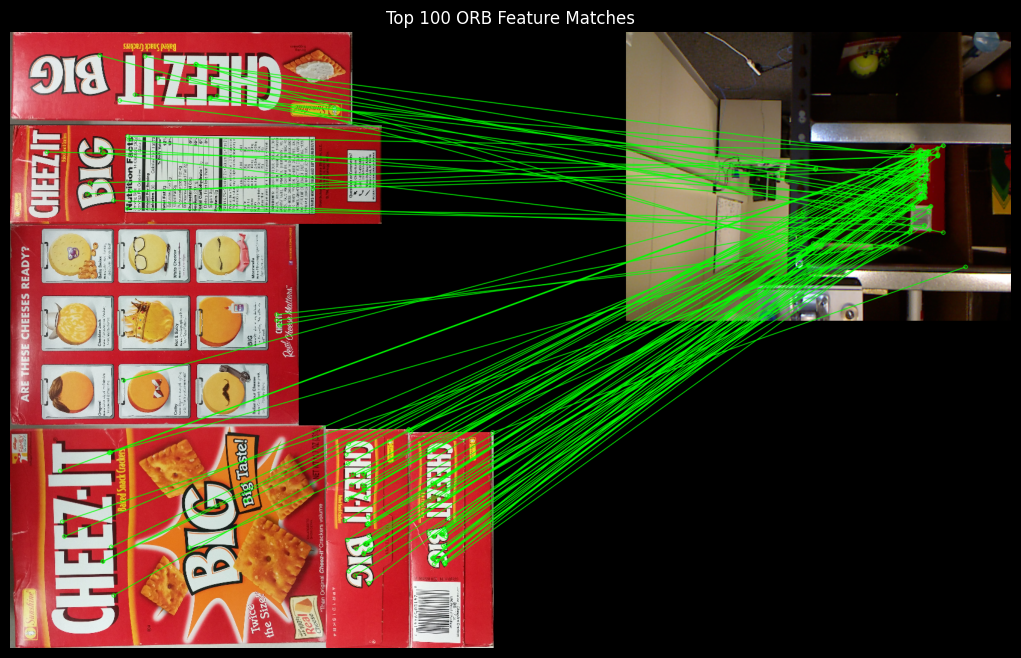

In [41]:
# Draw the matches! We pass the color images here so the visualization looks nicer.
draw_feature_matches(template_img, kp_temp, rgb_img, kp_scene, good_matches)

In [26]:
def estimate_pose_from_matches(kp_temp, kp_scene, matches, K, dist_coeffs):
    """Uses the matched keypoints to estimate the 6-DOF pose using PnP."""
    # PnP requires at least 4 points to solve for a pose
    if len(matches) < 4:
        print("Error: Not enough matches to compute pose.")
        return None, None

    # Extract 2D coordinates of the matches
    pts_template = np.float32([kp_temp[m.queryIdx].pt for m in matches])
    pts_scene = np.float32([kp_scene[m.trainIdx].pt for m in matches])

    # Approximate 3D Object Points (Assuming a flat Z=0 plane for the template face)
    obj_points_3d = np.zeros((len(pts_template), 3), dtype=np.float32)
    obj_points_3d[:, 0] = pts_template[:, 0] # X coordinates
    obj_points_3d[:, 1] = pts_template[:, 1] # Y coordinates

    # Solve PnP (Perspective-n-Point) to find Rotation and Translation
    success, rvec, tvec, inliers = cv2.solvePnPRansac(
        obj_points_3d, pts_scene, K, dist_coeffs,
        reprojectionError=8.0, iterationsCount=100
    )

    if success:
        # Convert the rotation vector into a 3x3 rotation matrix
        R_est, _ = cv2.Rodrigues(rvec)
        return R_est, tvec
    else:
        print("Pose estimation failed to find enough inliers.")
        return None, None

In [27]:
def calculate_pose_error(R_est, t_est, gt_pose: Pose):
    # 1. Translational Error (L2 Euclidean Distance)
    # distance = sqrt( (x1-x2)^2 + (y1-y2)^2 + (z1-z2)^2 )
    trans_error = np.linalg.norm(t_est - gt_pose.translation)

    # 2. Rotational Error (Angle distance)
    # Using the formula: theta = arccos( (trace(R_est * R_gt^T) - 1) / 2 )
    R_gt = gt_pose.rotation
    R_diff = np.dot(R_est, R_gt.T)
    trace = np.trace(R_diff)

    # Clip trace to [-1, 3] to avoid floating point errors causing NaNs in arccos
    trace = np.clip(trace, -1.0, 3.0)
    rot_error_rad = math.acos((trace - 1.0) / 2.0)
    rot_error_deg = math.degrees(rot_error_rad)

    return trans_error, rot_error_deg

In [42]:
# Calculate the estimated rotation and translation matrices
R_est, t_est = estimate_pose_from_matches(kp_temp, kp_scene, good_matches, K, dist_coeffs)

if R_est is not None:
    print("Estimated Translation Vector:\n", t_est)

    # Evaluate against the ground truth using our error calculation function
    t_err, r_err = calculate_pose_error(R_est, t_est, obj_data.pose)
    print(f"\n--- Accuracy Report ---")
    print(f"Translational Error: {t_err:.4f} meters")
    print(f"Rotational Error: {r_err:.4f} degrees")

Estimated Translation Vector:
 [[  63.31692653]
 [ 206.94929326]
 [-177.385327  ]]

--- Accuracy Report ---
Translational Error: 280.2040 meters
Rotational Error: 31.5334 degrees


Possible code

In [ ]:
def estimate_pose_pnp(template_gray, scene_gray, K, dist_coeffs):
    # 1. Initialize ORB detector
    orb = cv2.ORB_create(nfeatures=1000)

    # 2. Find keypoints and descriptors
    kp_temp, des_temp = orb.detectAndCompute(template_gray, None)
    kp_scene, des_scene = orb.detectAndCompute(scene_gray, None)

    # 3. Match features using Brute Force Matcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des_temp, des_scene)
    matches = sorted(matches, key=lambda x: x.distance)

    # Keep only the top matches to reduce noise
    good_matches = matches[:50]

    # 4. Extract 2D coordinates of the matches
    pts_template = np.float32([kp_temp[m.queryIdx].pt for m in good_matches])
    pts_scene = np.float32([kp_scene[m.trainIdx].pt for m in good_matches])

    # 5. Approximate 3D Object Points
    # For a planar object face (like Cheez-It), we assume Z=0 for the template surface.
    # In a perfect pipeline, you'd map these to the exact 3D mesh vertices.
    obj_points_3d = np.zeros((len(pts_template), 3), dtype=np.float32)
    obj_points_3d[:, 0] = pts_template[:, 0] # X
    obj_points_3d[:, 1] = pts_template[:, 1] # Y
    # Z remains 0

    # 6. Solve PnP (Perspective-n-Point) to find Rotation and Translation
    success, rvec, tvec, inliers = cv2.solvePnPRansac(
        obj_points_3d, pts_scene, K, dist_coeffs,
        reprojectionError=8.0, iterationsCount=100
    )

    if success:
        # Convert rotation vector to 3x3 rotation matrix
        R_est, _ = cv2.Rodrigues(rvec)
        return R_est, tvec
    else:
        print("Pose estimation failed to find enough inliers.")
        return None, None

R_est, t_est = estimate_pose_pnp(template_gray, masked_scene, K, dist_coeffs)

print("Estimated Translation:\n", t_est)